In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

Mounted at /content/drive


# DNA

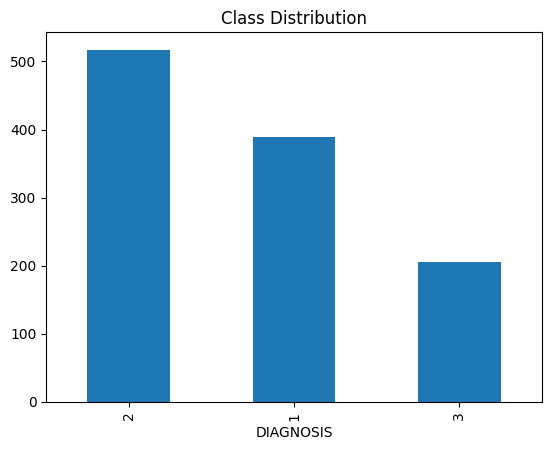

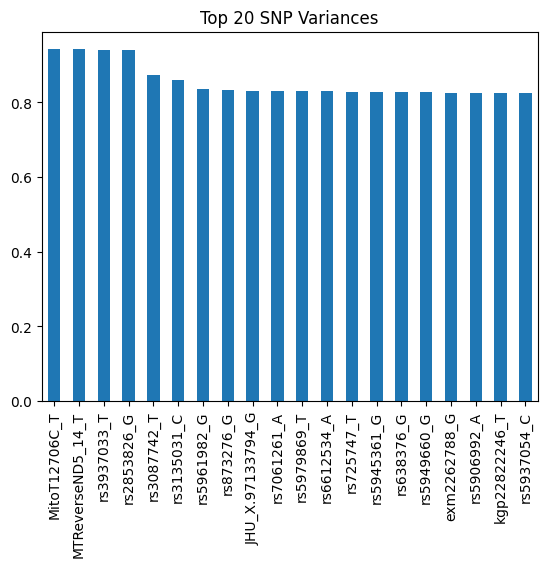

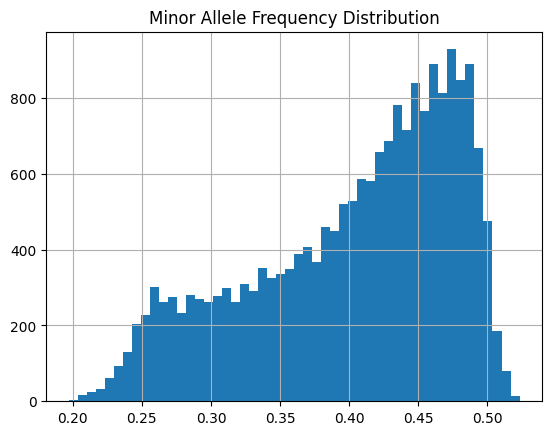

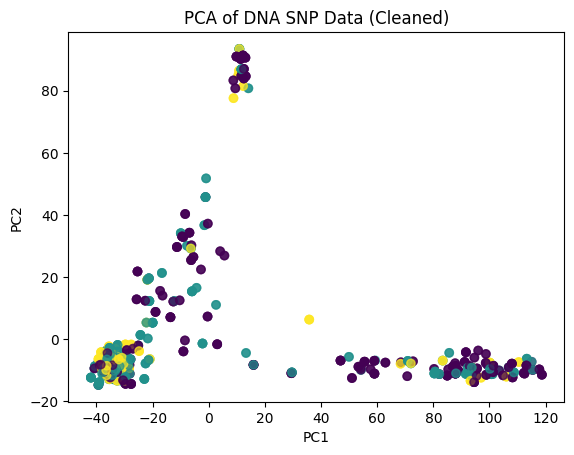

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

dna = pd.read_csv("ADNI3_DNA_cleaned.csv")
dna["DIAGNOSIS"] = dna["DIAGNOSIS"].fillna(0).astype(int)

# Keep only SNP numerical columns (exclude non-genotypes)
non_snp_cols = ['PTID','RID','VISCODE','EXAMDATE','PHASE','DIAGNOSIS']
snp_data = dna.drop(columns=non_snp_cols, errors='ignore').select_dtypes(include=['number'])

# If exception columns are still mixed in, further filtering will only include {0,1,2}
valid_snp_cols = [c for c in snp_data.columns
                  if dna[c].dropna().isin([0,1,2]).all()]
snp_data = dna[valid_snp_cols]

dna['DIAGNOSIS'].value_counts().plot(kind='bar', title="Class Distribution")
plt.show()

variances = snp_data.var().sort_values(ascending=False)
variances.head(20).plot(kind='bar', title="Top 20 SNP Variances")
plt.show()

maf = snp_data.sum(axis=0) / (2 * len(snp_data))
maf.hist(bins=50)
plt.title("Minor Allele Frequency Distribution")
plt.show()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(snp_data.fillna(0))

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)
plt.scatter(
    pca_result[:, 0],
    pca_result[:, 1],
    c=dna['DIAGNOSIS'],
    cmap='viridis',
    alpha=0.7
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of DNA SNP Data (Cleaned)")
plt.show()

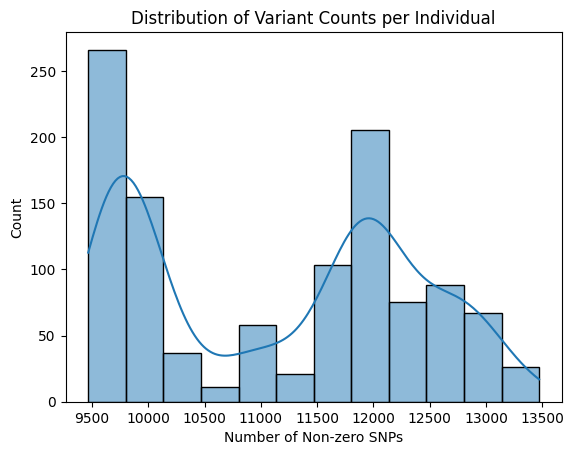

In [ ]:
variant_counts = (snp_data > 0).sum(axis=1)
sns.histplot(variant_counts, kde=True)
plt.title("Distribution of Variant Counts per Individual")
plt.xlabel("Number of Non-zero SNPs")
plt.show()


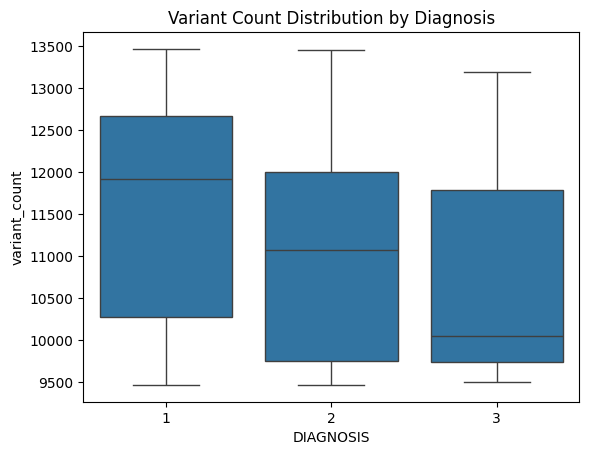

In [ ]:
variant_counts = (snp_data > 0).sum(axis=1)
dna['variant_count'] = variant_counts

sns.boxplot(x='DIAGNOSIS', y='variant_count', data=dna)
plt.title("Variant Count Distribution by Diagnosis")
plt.show()

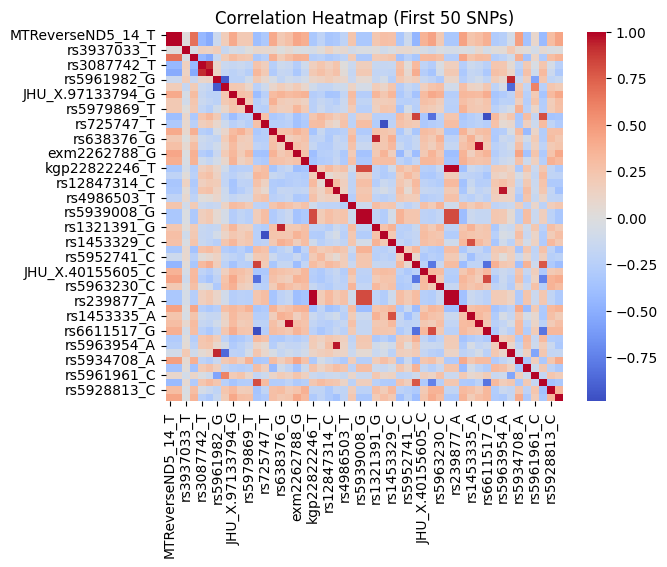

In [ ]:
corr_matrix = snp_data.iloc[:, :50].corr()
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap (First 50 SNPs)")
plt.show()

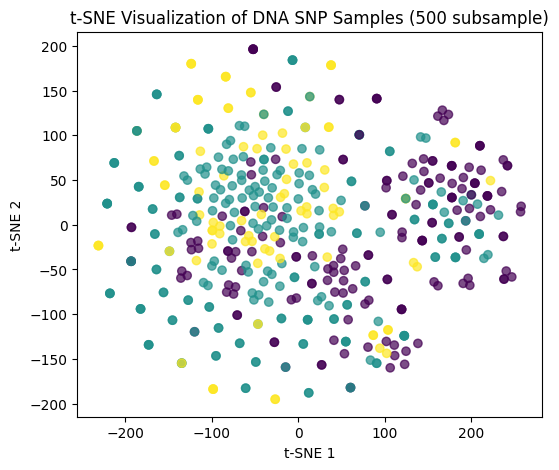

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

subset = dna.sample(500, random_state=42)
snp_subset = snp_data.loc[subset.index]

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_result = tsne.fit_transform(snp_subset)

plt.figure(figsize=(6,5))
plt.scatter(
    tsne_result[:,0],
    tsne_result[:,1],
    c=subset['DIAGNOSIS'],
    cmap='viridis',
    alpha=0.7)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE Visualization of DNA SNP Samples (500 subsample)")
plt.show()


# RNA

样本数: 744, 特征数: 19052


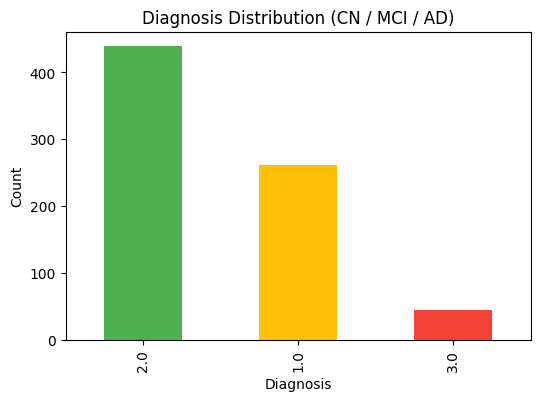

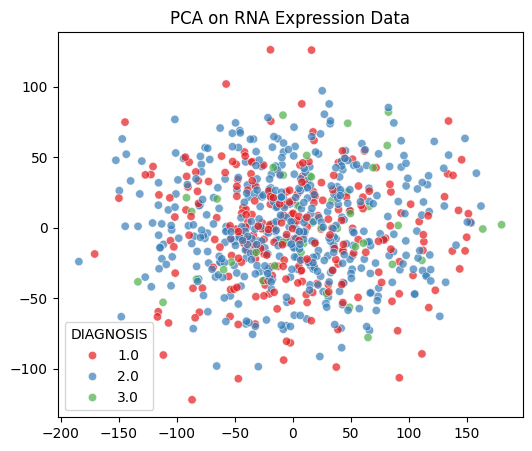

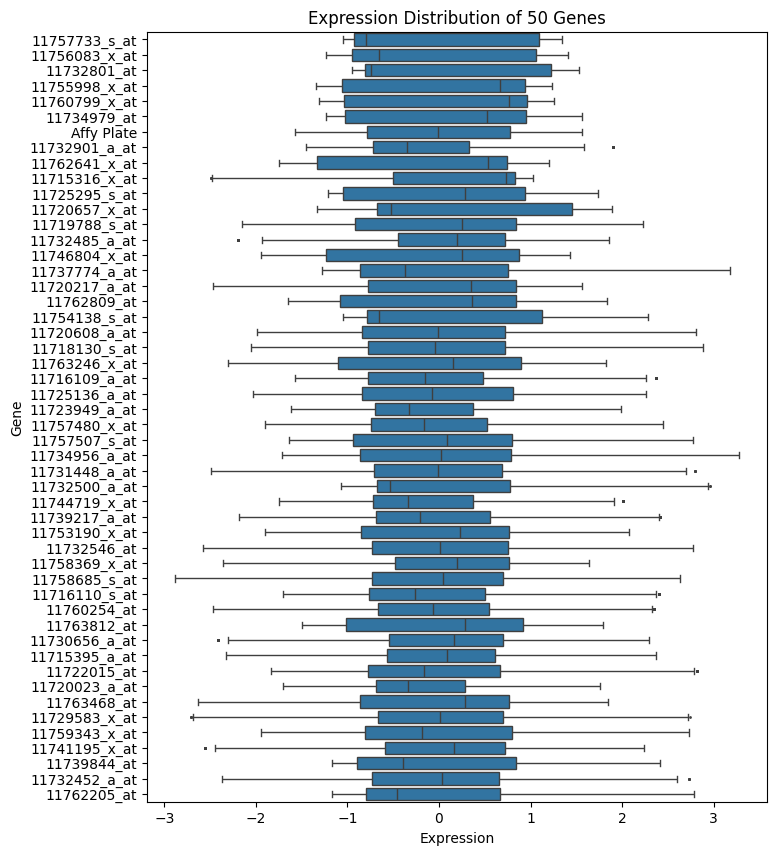

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

df = pd.read_csv("RNA_cleaned.csv")

print(f"Number of samples: {df.shape[0]}, Number of features: {df.shape[1]}")

plt.figure(figsize=(6,4))
df['DIAGNOSIS'].value_counts().plot(kind='bar', color=['#4CAF50','#FFC107','#F44336'])
plt.title("Diagnosis Distribution (CN / MCI / AD)")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()

X = df.drop(columns=['subject_id','DIAGNOSIS'])
y = df['DIAGNOSIS']

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(6,5))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y, palette="Set1", alpha=0.7)
plt.title("PCA on RNA Expression Data")
plt.show()


subset_genes = X.iloc[:, :50]

subset_long = subset_genes.melt(var_name="Gene", value_name="Expression")

plt.figure(figsize=(8,10))
sns.boxplot(x="Expression", y="Gene", data=subset_long, fliersize=1)
plt.title("Expression Distribution of 50 Genes")
plt.show()

In [ ]:
df.head()

,DIAGNOSIS,subject_id,11757733_s_at,11756083_x_at,11732801_at,11755998_x_at,11760799_x_at,11734979_at,Affy Plate,11732901_a_at,...,11754125_x_at,11740840_a_at,11732132_a_at,11754341_s_at,11729358_a_at,11739714_a_at,11750571_a_at,11741066_a_at,11739035_x_at,11761777_x_at
0,1.0,002_S_0413,0.959871,0.973369,-0.684698,0.992363,1.189689,1.082682,-1.182478,-0.278854,...,1.170711,0.509101,-0.734787,1.117417,1.570516,-0.095833,-0.309023,0.581787,0.393271,-0.164110
1,1.0,002_S_0685,1.240906,1.211647,-0.800197,-1.179988,1.008529,0.854665,-1.574355,1.897489,...,0.372973,-0.185340,1.907642,-2.679504,1.263367,-0.283107,1.455397,1.046936,-1.053156,-1.240335
2,2.0,002_S_0729,1.136076,-1.032681,1.476511,-1.283801,-1.115255,0.803080,-1.574355,-0.797053,...,-0.110304,-0.469730,0.457089,0.499089,0.338580,1.335476,0.307700,1.425472,0.526538,1.780141
3,2.0,002_S_1155,-0.968217,-0.846900,-0.782275,1.182488,0.992536,-1.070776,-0.006847,0.094838,...,-0.649854,0.287542,0.660101,0.244673,-0.168884,-0.741259,-1.928331,0.905787,-0.039032,-0.442775
4,1.0,002_S_1261,1.233224,-0.439978,-0.768051,1.034481,1.082962,0.710004,1.168784,0.584504,...,0.237258,-1.164172,-0.515403,-0.473490,-1.934992,-0.008884,0.752927,2.554663,-0.035781,-1.454939


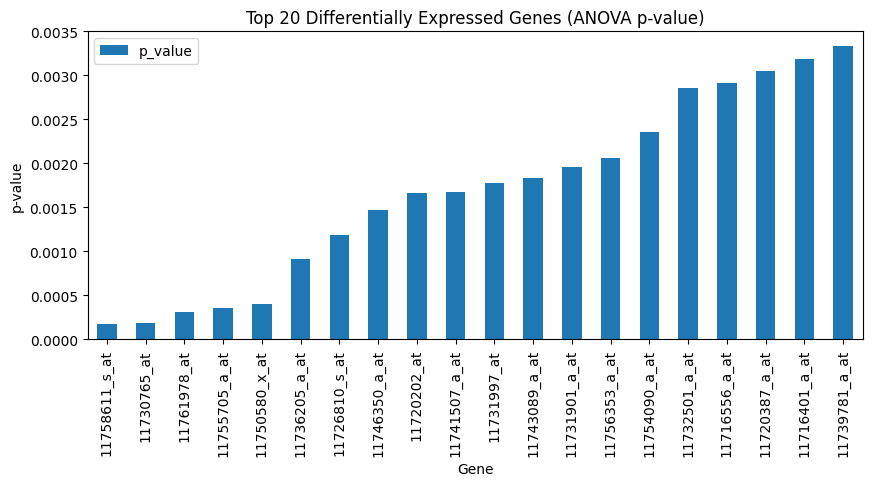

In [ ]:
from scipy.stats import f_oneway
import numpy as np

pvals = []
for col in X.columns[:1000]:
    groups = [X[y==cls][col] for cls in y.unique()]
    pvals.append((col, f_oneway(*groups)[1]))

pval_df = pd.DataFrame(pvals, columns=['Gene','p_value']).sort_values('p_value')
pval_df.head(20).plot(kind='bar', x='Gene', y='p_value', figsize=(10,4))
plt.title("Top 20 Differentially Expressed Genes (ANOVA p-value)")
plt.ylabel("p-value")
plt.show()


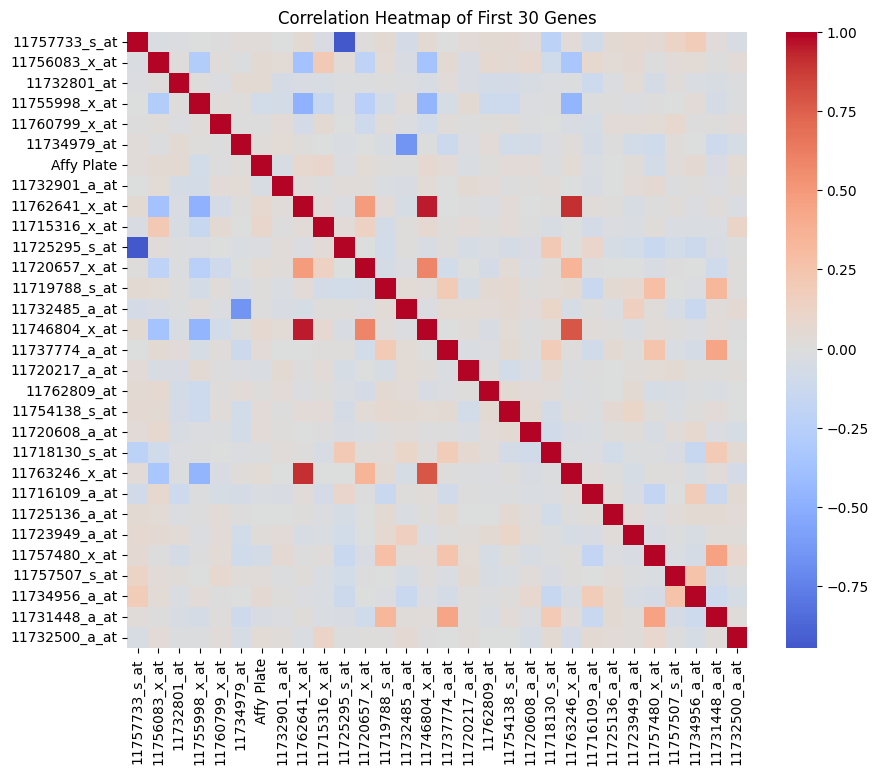

In [ ]:
corr = X.iloc[:, :30].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap of First 30 Genes")
plt.show()


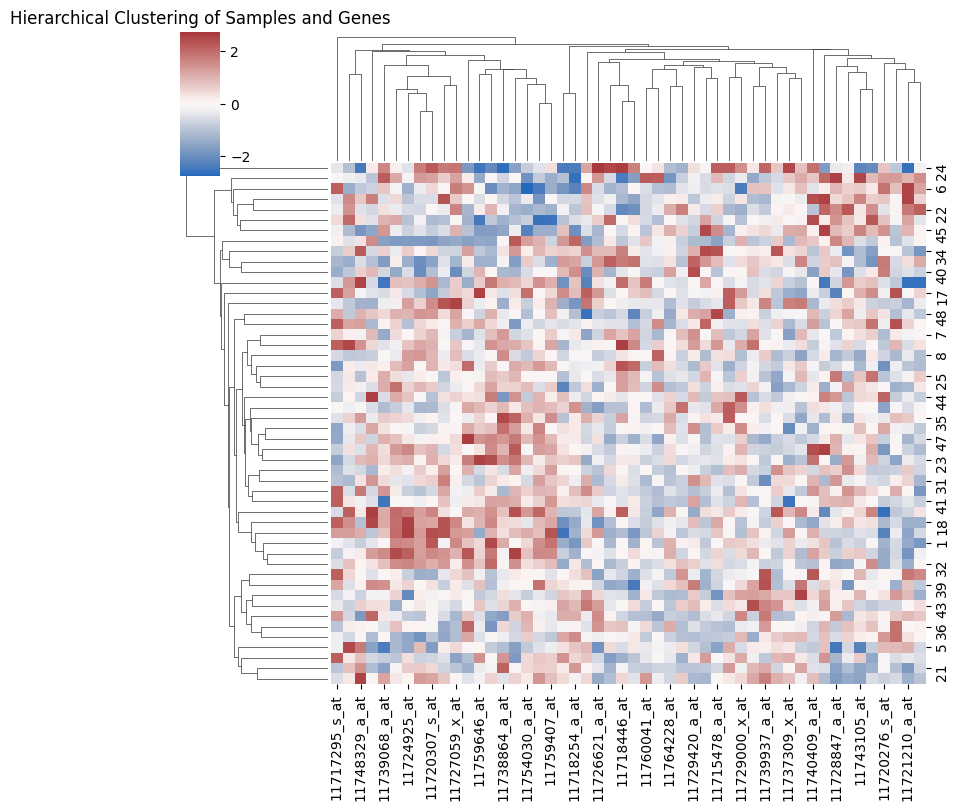

In [ ]:
sns.clustermap(X[top_var_genes].iloc[:50], cmap="vlag", figsize=(8,8))
plt.title("Hierarchical Clustering of Samples and Genes")
plt.show()


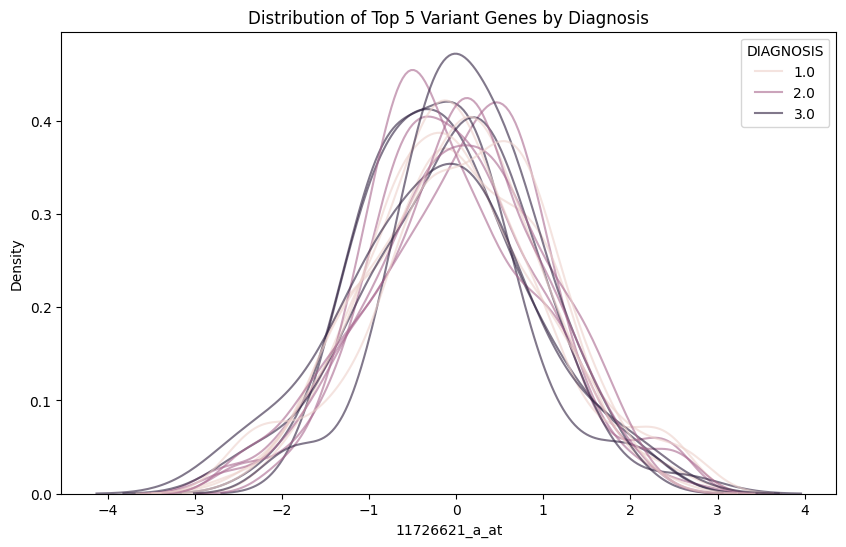

In [ ]:
top5 = top_var_genes[:5]
plt.figure(figsize=(10,6))
for g in top5:
    sns.kdeplot(data=df, x=g, hue='DIAGNOSIS', common_norm=False, alpha=0.6)
plt.title("Distribution of Top 5 Variant Genes by Diagnosis")
plt.show()


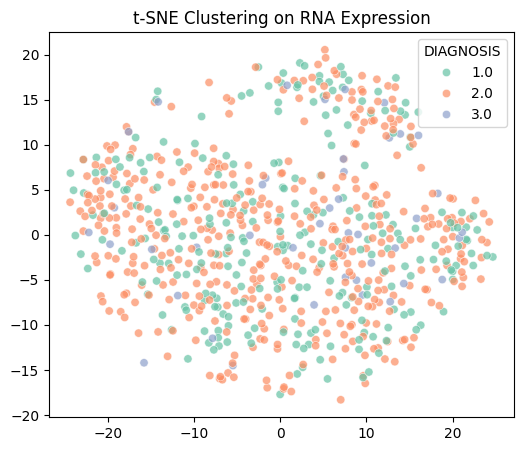

In [ ]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(6,5))
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=y, palette="Set2", alpha=0.7)
plt.title("t-SNE Clustering on RNA Expression")
plt.show()


# MRI

In [ ]:
import os
import pandas as pd

base_dir = "Sampled MRI/"

data_counts = {}
for cls in os.listdir(base_dir):
    cls_path = os.path.join(base_dir, cls)
    if os.path.isdir(cls_path):
        data_counts[cls] = len(os.listdir(cls_path))

print(data_counts)


{'NC': 3000, 'MCI': 3000, 'AD': 3000}


In [ ]:
from PIL import Image

sample_file = os.path.join(base_dir, "AD", os.listdir(os.path.join(base_dir,"AD"))[0])
img = Image.open(sample_file)
print(img.size, img.mode)


(224, 224) L


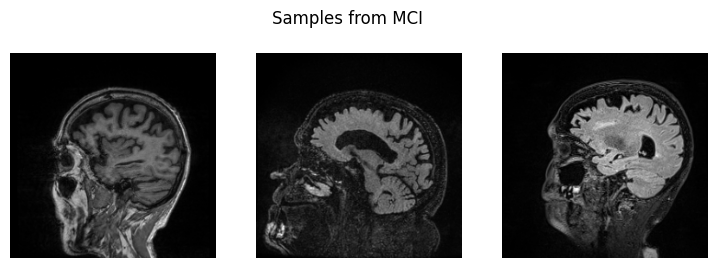

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import random

cls = "MCI"
cls_path = os.path.join(base_dir, cls)

files = random.sample(os.listdir(cls_path), 3)

plt.figure(figsize=(9,3))
for i, f in enumerate(files):
    img = Image.open(os.path.join(cls_path, f)).convert("L")  # 转灰度
    plt.subplot(1, 3, i+1)
    plt.imshow(img, cmap="gray")
    plt.axis("off")
plt.suptitle(f"Samples from {cls}")
plt.show()


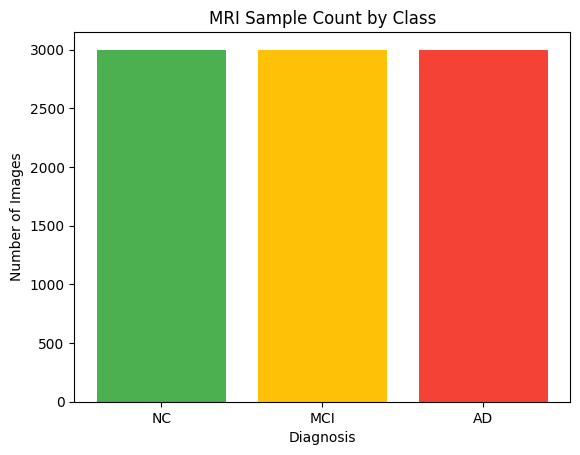

In [ ]:
import matplotlib.pyplot as plt

data_counts = {'NC': 3000, 'MCI': 3000, 'AD': 3000}
plt.bar(data_counts.keys(), data_counts.values(), color=['#4CAF50','#FFC107','#F44336'])
plt.title("MRI Sample Count by Class")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Images")
plt.show()


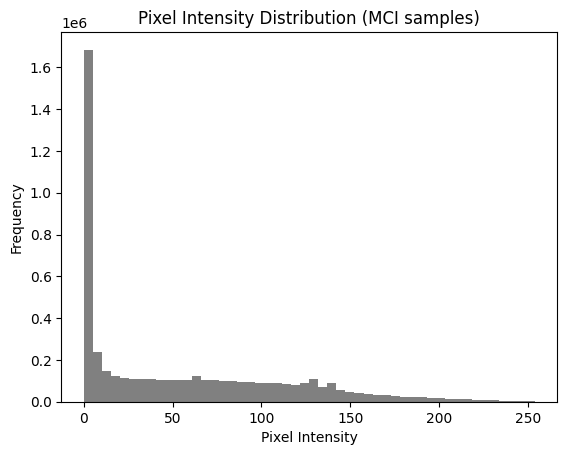

In [ ]:
import numpy as np
from PIL import Image
import os, random

cls_path = os.path.join(base_dir, "MCI")
sample_files = random.sample(os.listdir(cls_path), 100)

pixel_values = []
for f in sample_files:
    img = Image.open(os.path.join(cls_path, f)).convert("L")
    pixel_values.extend(np.array(img).flatten())

plt.hist(pixel_values, bins=50, color='gray')
plt.title("Pixel Intensity Distribution (MCI samples)")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()


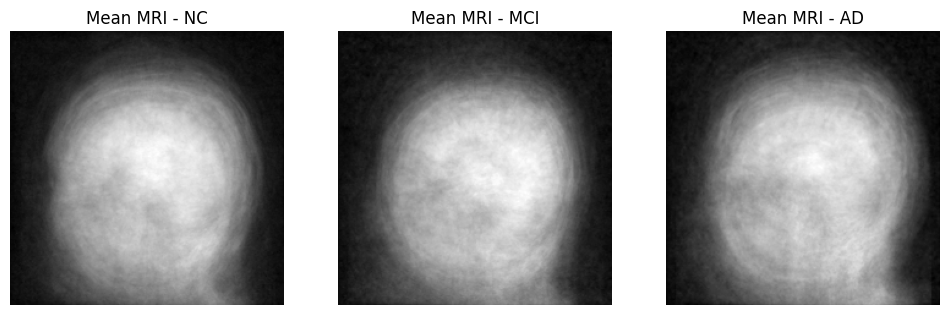

In [ ]:
import numpy as np

def mean_image(cls):
    cls_path = os.path.join(base_dir, cls)
    files = random.sample(os.listdir(cls_path), 200)
    imgs = [np.array(Image.open(os.path.join(cls_path, f)).convert("L")) for f in files]
    return np.mean(imgs, axis=0)

mean_nc = mean_image("NC")
mean_mci = mean_image("MCI")
mean_ad = mean_image("AD")

fig, axes = plt.subplots(1,3, figsize=(12,4))
for ax, img, title in zip(axes, [mean_nc, mean_mci, mean_ad], ["NC", "MCI", "AD"]):
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Mean MRI - {title}")
    ax.axis("off")
plt.show()


/tmp/ipython-input-2569639416.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="class", y="mean_intensity", data=df_stats, palette="Set2")


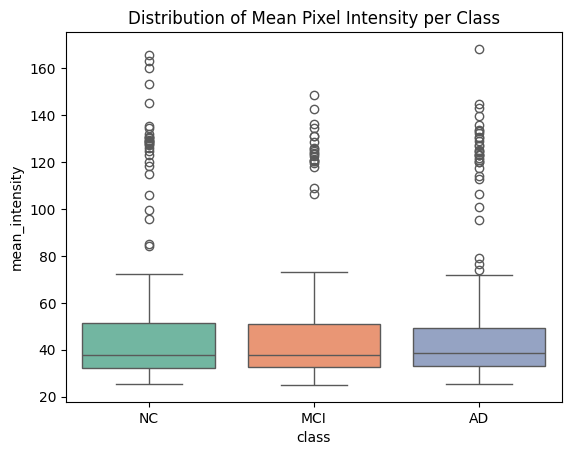

In [ ]:
import pandas as pd

records = []
for cls in ["NC", "MCI", "AD"]:
    cls_path = os.path.join(base_dir, cls)
    files = random.sample(os.listdir(cls_path), 200)
    for f in files:
        img = np.array(Image.open(os.path.join(cls_path, f)).convert("L"))
        records.append({
            "class": cls,
            "mean_intensity": np.mean(img),
            "variance": np.var(img)
        })

df_stats = pd.DataFrame(records)
sns.boxplot(x="class", y="mean_intensity", data=df_stats, palette="Set2")
plt.title("Distribution of Mean Pixel Intensity per Class")
plt.show()


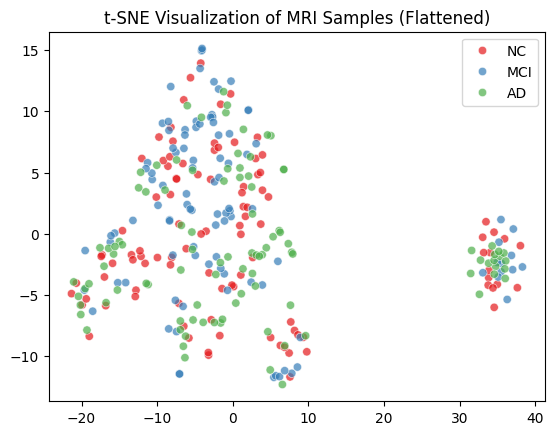

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

def sample_images(cls, n=100):
    cls_path = os.path.join(base_dir, cls)
    files = random.sample(os.listdir(cls_path), n)
    return [np.array(Image.open(os.path.join(cls_path, f)).convert("L")).flatten() for f in files], [cls]*n

X, y = [], []
for c in ["NC", "MCI", "AD"]:
    Xi, yi = sample_images(c)
    X += Xi
    y += yi
X = np.array(X)

pca = PCA(n_components=50).fit_transform(X)
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(pca)

sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=y, palette="Set1", alpha=0.7)
plt.title("t-SNE Visualization of MRI Samples (Flattened)")
plt.show()
